In [401]:
import tensorflow as tf

In [402]:
histos={}
nb_epochs = 10

In [403]:
data = tf.keras.datasets.fashion_mnist
(training_images, training_labels), (test_images, test_labels) = data.load_data()

In [404]:
training_images.shape, training_images

((60000, 28, 28),
 array([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        ...,
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0,

In [405]:
training_images.ndim

3

In [406]:
test_images.shape

(10000, 28, 28)

In [407]:
training_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [408]:
training_labels.shape

(60000,)

In [409]:
test_labels

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [410]:
labels = ["t-shirt/top", "trouser", "pullover", "dress", "coat", "sandals", "shirt",
         "sneaker", "bag", "ankle boot"]

In [411]:
labels[8]

'bag'

In [412]:
training_images[45]

array([[  0,   0,   0,   1,   0,   0,   0,   0,   0,  34, 148, 202, 107,
         84, 162, 198,  90,  26,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  21, 107, 166, 168, 152, 204, 238,
        248, 237, 190, 142, 178, 158,  98,  17,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,  55, 188, 140, 131, 121, 119, 116, 146,
        157, 132, 115, 136, 125, 140, 143, 181,  51,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 167, 134, 113, 130, 134, 140, 132, 125,
        125, 131, 135, 130, 133, 131, 115, 135, 163,   6,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  58, 148, 133, 124, 134, 128, 135, 128, 133,
        130, 133, 137, 138, 130, 124, 130, 133, 147,  82,   0,   1,   0,
          0,   0],
       [  0,   0,   0,   0,  86, 148, 158, 139, 124, 120, 131, 134, 132,
        134, 124, 134, 132, 137, 126, 137, 136, 146, 114,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 112, 141, 174, 143, 117, 134, 130, 128, 131,
        136, 134, 128, 128, 131, 106, 187, 149, 147, 143,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 134, 151, 167, 154, 114, 134, 138, 139, 135,
        135, 130, 130, 124, 129, 119, 229, 141, 145, 164,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 154, 169, 157, 109, 147, 140, 137, 137,
        136, 142, 141, 139, 129, 123, 201, 146, 138, 172,  21,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 145, 158, 171, 175, 111, 136, 145, 136, 135,
        138, 137, 143, 146, 140, 122, 184, 167, 136, 170,  58,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 151, 155, 189, 183, 120, 135, 132, 136, 135,
        133, 128, 130, 134, 120, 153, 230, 156, 135, 167,  83,   0,   0,
          0,   0],
       [  0,   0,   0,   1, 166, 151, 208, 175, 116, 142, 144, 138, 149,
        133, 131, 137, 140, 119, 126, 206, 198, 141, 166, 101,   0,   0,
          0,   0],
       [  0,   0,   0,   6, 169, 146, 237, 187, 104, 131, 136, 149, 147,
        137, 137, 137, 132, 137, 113, 166, 206, 151, 162, 126,   0,   0,
          0,   0],
       [  0,   0,   0,  20, 180, 136, 231, 214, 105, 134, 140, 139, 136,
        137, 136, 148, 134, 149, 111, 139, 255, 151, 158, 147,   0,   0,
          0,   0],
       [  0,   0,   0,  33, 184, 109, 217, 182, 105, 124, 143, 131, 135,
        137, 139, 138, 131, 142, 132,  99, 249, 162, 157, 172,   0,   0,
          0,   0],
       [  0,   0,   0,  35, 180, 112, 233, 143, 109, 133, 145, 146, 142,
        142, 139, 141, 135, 141, 152, 101, 205, 163, 154, 170,   0,   0,
          0,   0],
       [  0,   0,   0,  42, 183, 123, 217, 117, 126, 137, 140, 134, 137,
        135, 143, 141, 133, 133, 149, 107, 166, 176, 153, 169,  14,   0,
          0,   0],
       [  0,   0,   0,  48, 175, 147, 210, 101, 119, 136, 142, 137, 142,
        139, 147, 142, 146, 126, 138, 102, 131, 197, 161, 183,  32,   0,
          0,   0],
       [  0,   0,   0,  56, 165, 163, 213,  74, 126, 138, 149, 133, 133,
        132, 141, 134, 142, 132, 132, 126, 117, 193, 162, 172,  39,   0,
          0,   0],
       [  0,   0,   0,  62, 157, 165, 227,  39, 135, 138, 136, 142, 146,
        143, 136, 138, 134, 141, 134, 116,  78, 197, 171, 156,  44,   0,
          0,   0],
       [  0,   0,   0,  65, 162, 169, 245,  39, 140, 133, 133, 128, 132,
        134, 143, 145, 134, 133, 134, 128,  36, 208, 172, 151,  55,   0,
          0,   0],
       [  0,   0,   0,  72, 147, 168, 244,  25, 142, 137, 138, 133, 128,
        132, 147, 145, 135, 136, 133, 131,  26, 207, 173, 149,  67,   0,
          0,   0],
       [  0,   0,   0,  68, 153, 179, 250,  11, 135, 134, 139, 133, 136,
        140, 140, 143, 145, 140, 131, 126,  32, 207, 175, 136,  73,   0,
          0,   0],
       [  0,   0,   0,  61, 155, 180, 252,  23, 151, 132, 131, 133, 133,
        129, 135, 140, 132, 139, 132, 139,  38, 221, 174, 135,  77,   0,
          0,   0],
       [  0,   0,   0,  18, 147, 187, 18

In [413]:
training_images.min(), training_images.max()

(np.uint8(0), np.uint8(255))

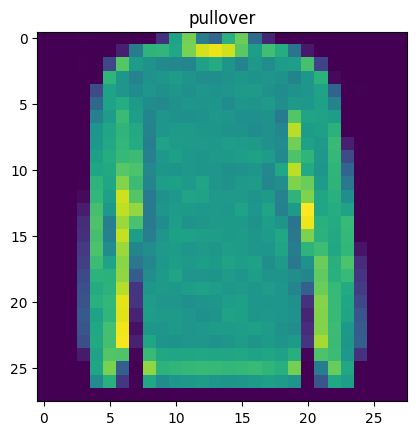

In [414]:
import matplotlib.pyplot as plt
plt.imshow(training_images[45])
plt.title(labels[training_labels[45]])
plt.show()

In [415]:
training_labels[45]

np.uint8(2)

In [416]:
labels[2]

'pullover'

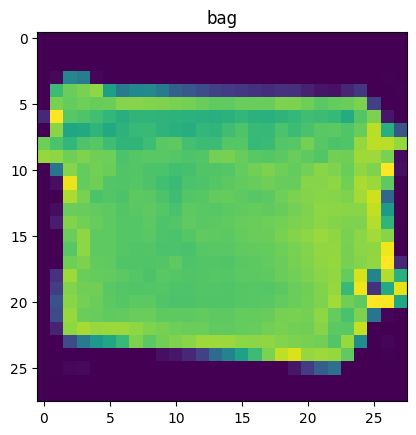

In [417]:
import matplotlib.pyplot as plt
plt.imshow(training_images[12345])
plt.title(labels[training_labels[12345]])
plt.show()

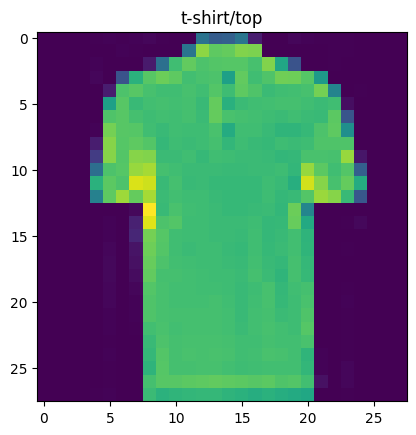

In [418]:
import matplotlib.pyplot as plt
plt.imshow(training_images[48978])
plt.title(labels[training_labels[48978]])
plt.show()

# Flatten (Applatir l'images)

In [419]:
training_images.shape

(60000, 28, 28)

In [420]:
a_training_images = training_images.reshape((60000, 28*28))
a_test_images = test_images.reshape(-1, 28*28) # -1 = toutes les images du dataset

In [421]:
a_training_images.shape, a_test_images.shape

((60000, 784), (10000, 784))

# One hot encoding

In [422]:
import numpy as np
x = np.array([1, 2, 1, 0, 3])

In [423]:
tf.keras.utils.to_categorical(x)

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.]])

In [424]:
training_labels.shape

(60000,)

In [425]:
training_labels = tf.keras.utils.to_categorical(training_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

In [426]:
training_labels.shape

(60000, 10)

In [427]:
training_labels[45]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

# Softmax

In [428]:
output = [6, 3, 2]

In [429]:
6/(6+3+2) + 3/(6+3+2) + 2/(6+3+2)

1.0

In [430]:
3/(6+3+2)

0.2727272727272727

In [431]:
6/(6+3+2)

0.5454545454545454

In [432]:
2/(6+3+2)

0.18181818181818182

In [433]:
import numpy as np

In [434]:
def softmax(vect):
  r = np.exp(np.array(vect))
  return r/sum(r)

In [435]:
softmax([6, 3, 2])

array([0.93623955, 0.04661262, 0.01714783])

In [436]:
[1, 0, 0]

[1, 0, 0]

# 1er modèle de classification

In [437]:
## Normalisation des données

In [438]:
a_training_images.min(), a_training_images.max()

(np.uint8(0), np.uint8(255))

In [439]:
a_training_images = a_training_images /255.0
a_test_images = a_test_images / 255.0

In [440]:
a_training_images.min(), a_training_images.max()

(np.float64(0.0), np.float64(1.0))

In [441]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

In [442]:
model = Sequential([ Dense(units=784, activation="sigmoid"),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="mse", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
# model.compile(loss="mse", optimizer=SGD(learning_rate=0.01))
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.2145 - loss: 0.0900 - val_accuracy: 0.3484 - val_loss: 0.0863
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.3579 - loss: 0.0852 - val_accuracy: 0.3922 - val_loss: 0.0820
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.3921 - loss: 0.0807 - val_accuracy: 0.4082 - val_loss: 0.0772
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.4194 - loss: 0.0759 - val_accuracy: 0.4636 - val_loss: 0.0724
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.4877 - loss: 0.0711 - val_accuracy: 0.5412 - val_loss: 0.0680
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.5733 - loss: 0.0668 - val_accuracy: 0.6257 - val_loss: 0.0639
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.6381 - loss: 0.0625 - val_accuracy: 0.6649 - val_loss: 0.0601
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.6671 - loss: 0

In [443]:
histos['MSE']=h

In [444]:
type(h)
summary = {
    k: [float(x) if x != "..." else "..." for x in (v[:3] + ["..."] + v[-3:])]
    for k, v in h.history.items()
}
"3 premières et 3 dernières valeurs :", dict(summary)

('3 premières et 3 dernières valeurs :',
 {'accuracy': [0.2720000147819519,
   0.3700999915599823,
   0.39871665835380554,
   '...',
   0.6725833415985107,
   0.6874666810035706,
   0.6967333555221558],
  'loss': [0.08843335509300232,
   0.08414023369550705,
   0.07950423657894135,
   '...',
   0.05820281431078911,
   0.05512126535177231,
   0.05249755457043648],
  'val_accuracy': [0.3483999967575073,
   0.3921999931335449,
   0.4081999957561493,
   '...',
   0.6851000189781189,
   0.6909000277519226,
   0.6972000002861023],
  'val_loss': [0.086326964199543,
   0.08195655792951584,
   0.07717715948820114,
   '...',
   0.056874509900808334,
   0.05405852571129799,
   0.051673389971256256]})

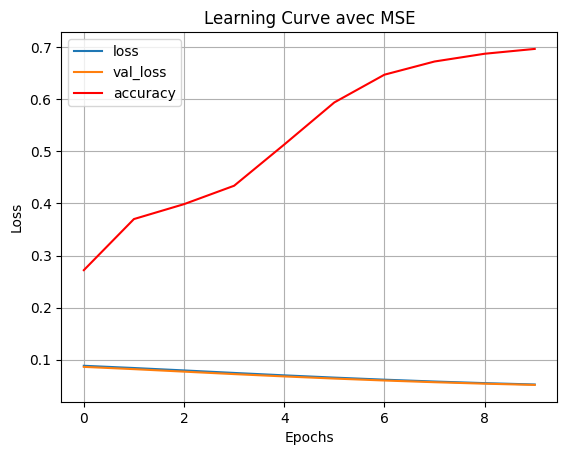

In [445]:
import matplotlib.pyplot as plt

def plot_learning_curve(history):

  plt.plot(list(range(len(history['loss']))), history['loss'], label='loss')
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label='val_loss')
  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label='accuracy', c='r')
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Learning Curve avec MSE")
  plt.legend()
  plt.grid()
  plt.show()

plot_learning_curve(h.history)

In [446]:
# accuracy: 0.5480 - loss: 0.0717 - val_accuracy: 0.5903 - val_loss: 0.0682

In [447]:
3/5

0.6

# MSE VS Cross-entropy ou Log loss

In [448]:
def mse(target, prediction):
  loss = (prediction-target) ** 2
  return loss

In [449]:
def log_loss(target, prediction):
  loss = - 1* np.log(prediction)
  return loss

In [450]:
prediction = np.arange(0, 1, 0.01)
prediction

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99])

In [451]:
target = np.ones_like(prediction)
target

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [452]:
loss_mse = mse(target, prediction)
loss_ce = log_loss(target, prediction)

/tmp/ipython-input-4183768036.py:2: RuntimeWarning: divide by zero encountered in log
  loss = - 1* np.log(prediction)


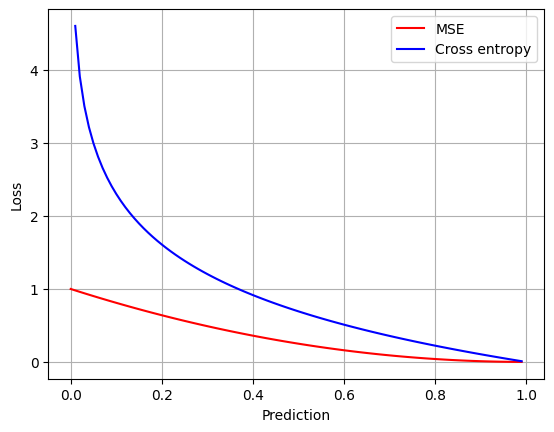

In [453]:
plt.plot(prediction, loss_mse, c='r', label='MSE')
plt.plot(prediction, loss_ce, c='b', label="Cross entropy")
plt.xlabel("Prediction")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid()
plt.show()

In [454]:
def log_loss(target, prediction):
  loss = - 1* np.log(1-prediction)
  return loss

In [455]:
np.zeros_like

<function zeros_like at 0x7ce56f733630>

In [456]:
target = np.zeros_like(prediction)
target

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [457]:
loss_mse = mse(target, prediction)
loss_ce = log_loss(target, prediction)

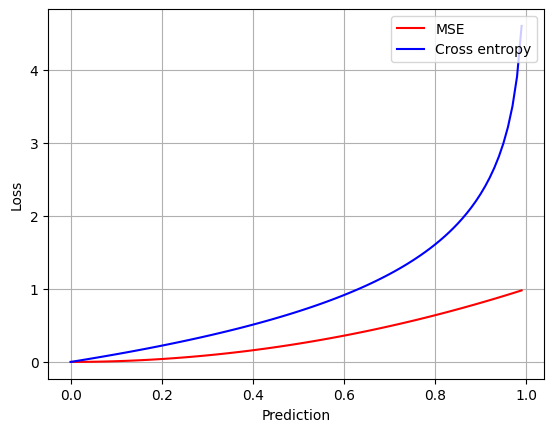

In [458]:
plt.plot(prediction, loss_mse, c='red', label='MSE')
plt.plot(prediction, loss_ce, c='blue', label="Cross entropy")
plt.xlabel("Prediction")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid()
plt.show()

# Entrainement avec cross entropy comme Loss

In [459]:
model = Sequential([ Dense(units=784, activation="sigmoid"),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.5765 - loss: 1.4761 - val_accuracy: 0.7387 - val_loss: 0.7924
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7586 - loss: 0.7347 - val_accuracy: 0.7725 - val_loss: 0.6616
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7803 - loss: 0.6306 - val_accuracy: 0.7837 - val_loss: 0.6095
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7962 - loss: 0.5839 - val_accuracy: 0.7931 - val_loss: 0.5787
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8064 - loss: 0.5509 - val_accuracy: 0.8045 - val_loss: 0.5596
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.8184 - loss: 0.5226 - val_accuracy: 0.8084 - val_loss: 0.5394
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8248 - loss: 0.5020 - val_accuracy: 0.8095 - val_loss: 0.5265
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8251 - loss: 0

In [460]:
histos['CROSS ENTROPY']=h

# Epoch 5/5
# MSE           : accuracy: 0.5523 - loss: 0.0708 - val_accuracy: 0.5839 - val_loss: 0.0674
# CROSS ENTROPY : accuracy: 0.8085 - loss: 0.5455 - val_accuracy: 0.8037 - val_loss: 0.5520

# Epoch 50/50
# MSE           : accuracy: 0.7930 - loss: 0.0310 - val_accuracy: 0.7834 - val_loss: 0.0319
# CROSS ENTROPY : accuracy: 0.8674 - loss: 0.3769 - val_accuracy: 0.8482 - val_loss: 0.4202

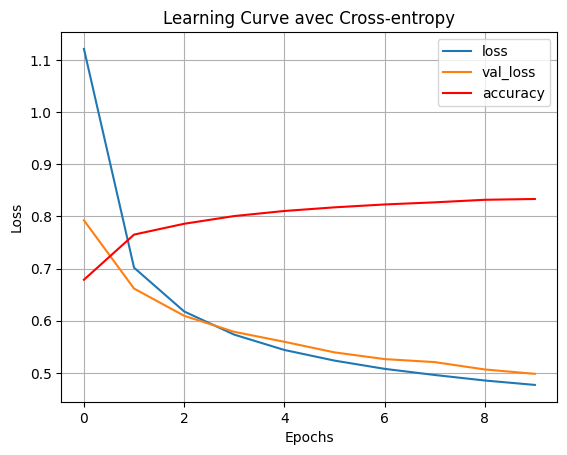

In [461]:
import matplotlib.pyplot as plt

def plot_learning_curve(history):

  plt.plot(list(range(len(history['loss']))), history['loss'], label='loss')
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label='val_loss')
  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label='accuracy', c='r')
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Learning Curve avec Cross-entropy")
  plt.legend()
  plt.grid()
  plt.show()

plot_learning_curve(h.history)

# Nouvelle fonction d'activation : Relu (REctified Linear Unit)

In [462]:
values = np.arange(-5, 5, 0.01)

In [463]:
sig = tf.nn.sigmoid(values)

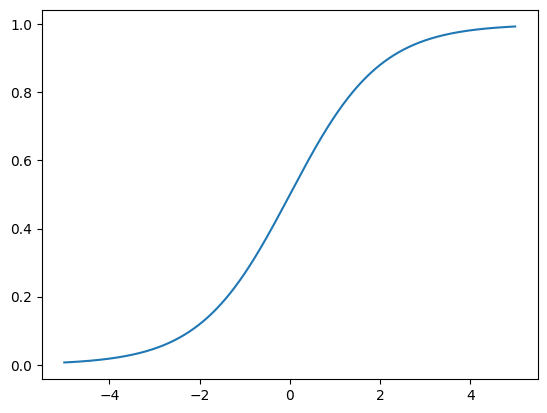

In [464]:
plt.plot(values, sig)
plt.show()

In [465]:
def relu(vect):
  return np.maximum(0, vect)

In [466]:
relu_values = relu(values)

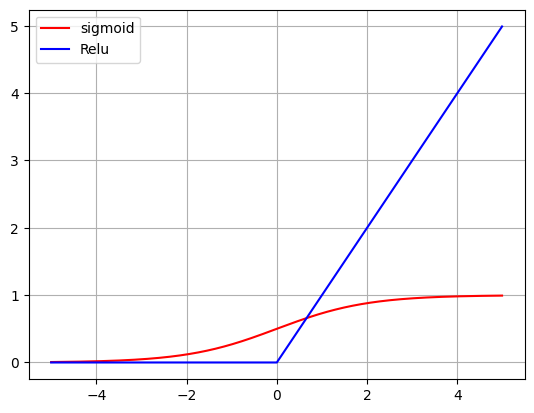

In [467]:
plt.plot(values, sig, c='r', label="sigmoid")
plt.plot(values, relu_values, c='b', label="Relu")
plt.legend(loc="upper left")
plt.grid()
plt.show()

In [468]:
model = Sequential([ Dense(units=784, activation="relu"),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.7057 - loss: 0.9359 - val_accuracy: 0.8180 - val_loss: 0.5427
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8316 - loss: 0.5021 - val_accuracy: 0.8343 - val_loss: 0.4894
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8434 - loss: 0.4624 - val_accuracy: 0.8367 - val_loss: 0.4644
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8514 - loss: 0.4335 - val_accuracy: 0.8442 - val_loss: 0.4440
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.8585 - loss: 0.4111 - val_accuracy: 0.8448 - val_loss: 0.4436
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8621 - loss: 0.3983 - val_accuracy: 0.8506 - val_loss: 0.4236
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8685 - loss: 0.3812 - val_accuracy: 0.8534 - val_loss: 0.4133
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8693 - loss: 0

In [469]:
histos['relu']=h
# Epoch 5/5
# MSE           : accuracy: 0.5523 - loss: 0.0708 - val_accuracy: 0.5839 - val_loss: 0.0674
# CROSS ENTROPY : accuracy: 0.8085 - loss: 0.5455 - val_accuracy: 0.8037 - val_loss: 0.5520
# relu          : accuracy: 0.8570 - loss: 0.4169 - val_accuracy: 0.8406 - val_loss: 0.4453

# Epoch 50/50
# MSE           : accuracy: 0.7930 - loss: 0.0310 - val_accuracy: 0.7834 - val_loss: 0.0319
# CROSS ENTROPY : accuracy: 0.8674 - loss: 0.3769 - val_accuracy: 0.8482 - val_loss: 0.4202
# relu          : accuracy: 0.9247 - loss: 0.2136 - val_accuracy: 0.8892 - val_loss: 0.3137

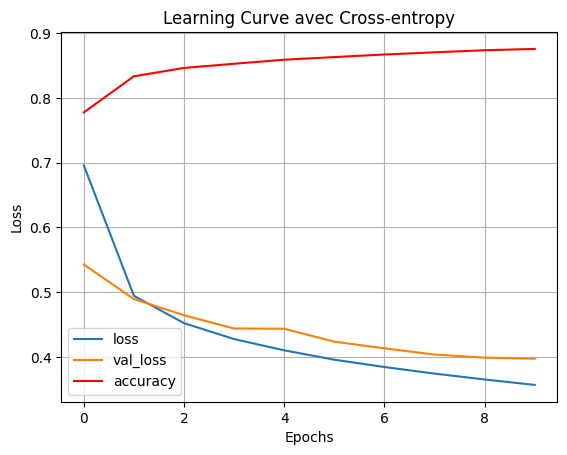

In [470]:
import matplotlib.pyplot as plt

def plot_learning_curve(history):

  plt.plot(list(range(len(history['loss']))), history['loss'], label='loss')
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label='val_loss')
  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label='accuracy', c='r')
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Learning Curve avec Cross-entropy")
  plt.legend()
  plt.grid()
  plt.show()

plot_learning_curve(h.history)

# Réseau de neurones plus complexe

In [471]:
model.summary()

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_79 (Dense)                │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (32, 10)               │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,292 (2.38 MB)

 Trainable params: 623,290 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [472]:
model = Sequential([ Dense(units=784, activation="relu"),
                     Dense(units=128, activation="relu"),
                     Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.7141 - loss: 0.9108 - val_accuracy: 0.8176 - val_loss: 0.5276
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8321 - loss: 0.4848 - val_accuracy: 0.8361 - val_loss: 0.4637
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8488 - loss: 0.4290 - val_accuracy: 0.8488 - val_loss: 0.4385
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8604 - loss: 0.4021 - val_accuracy: 0.8460 - val_loss: 0.4400
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8675 - loss: 0.3790 - val_accuracy: 0.8535 - val_loss: 0.4127
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8692 - loss: 0.3718 - val_accuracy: 0.8568 - val_loss: 0.4008
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8732 - loss: 0.3588 - val_accuracy: 0.8511 - val_loss: 0.4009
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8818 - loss: 0

In [473]:
histos['complexe']=h
# Epoch 5/5
# MSE            : accuracy: 0.5523 - loss: 0.0708 - val_accuracy: 0.5839 - val_loss: 0.0674
# CROSS ENTROPY  : accuracy: 0.8085 - loss: 0.5455 - val_accuracy: 0.8037 - val_loss: 0.5520
# relu           : accuracy: 0.8570 - loss: 0.4169 - val_accuracy: 0.8406 - val_loss: 0.4453
# model complexe : accuracy: 0.8676 - loss: 0.3768 - val_accuracy: 0.8541 - val_loss: 0.4082

# Epoch 50/50
# MSE            : accuracy: 0.7930 - loss: 0.0310 - val_accuracy: 0.7834 - val_loss: 0.0319
# CROSS ENTROPY  : accuracy: 0.8674 - loss: 0.3769 - val_accuracy: 0.8482 - val_loss: 0.4202
# relu           : accuracy: 0.9247 - loss: 0.2136 - val_accuracy: 0.8892 - val_loss: 0.3137
# model complexe :

In [474]:
model.summary()

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_81 (Dense)                │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (32, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 717,212 (2.74 MB)

 Trainable params: 717,210 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [475]:
import matplotlib.pyplot as plt


def plot_loss_curve(history):

  plt.plot(list(range(len(history['loss']))), history['loss'], label = "loss")
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label="val_loss")
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Loss Curve")
  plt.legend(loc='upper right')
  plt.show()


def plot_accuracy_curve(history):

  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label = "accuracy")
  plt.plot(list(range(len(history['val_accuracy']))), history['val_accuracy'], label="val_accuracy")
  plt.xlabel('Epochs')
  plt.ylabel("accuracy")
  plt.title("Accuracy Curve")
  plt.legend(loc='upper left')
  plt.show()


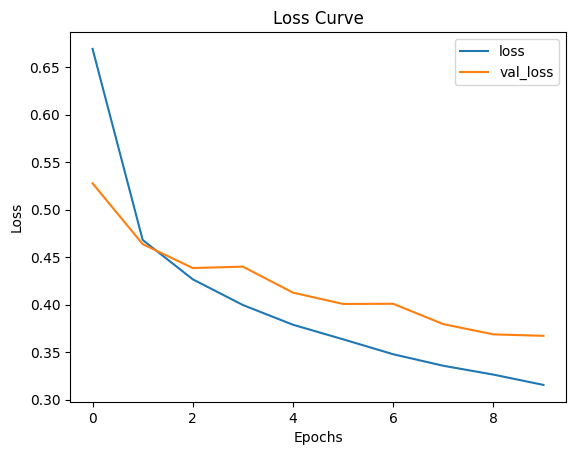

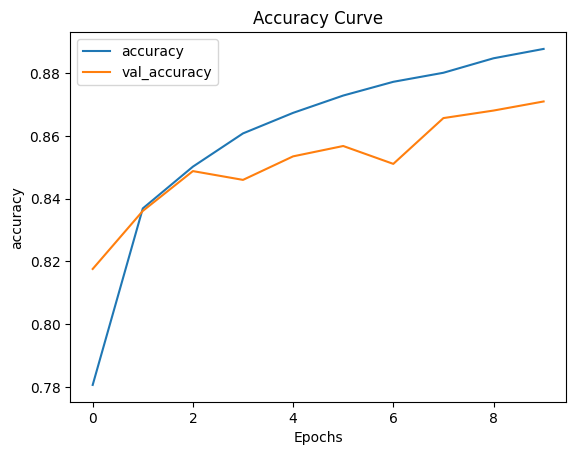

In [476]:
plot_loss_curve(h.history)
plot_accuracy_curve(h.history)

# Combattre le overfitting : Dropout

In [477]:
dropout = tf.keras.layers.Dropout(0.5, input_shape=(2,))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/dropout.py:42: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [478]:
# ?tf.keras.layers.Dropout

In [479]:
x = np.arange(1,11).reshape(5, 2).astype(np.float32)

In [480]:
x

array([[ 1.,  2.],
       [ 3.,  4.],
       [ 5.,  6.],
       [ 7.,  8.],
       [ 9., 10.]], dtype=float32)

In [481]:
dropout(x, training=True)

<tf.Tensor: shape=(5, 2), dtype=float32, numpy=
array([[ 0.,  4.],
       [ 6.,  8.],
       [ 0.,  0.],
       [14., 16.],
       [18., 20.]], dtype=float32)>

In [482]:
model = Sequential([ Dense(units=784, activation="relu"),
                    tf.keras.layers.Dropout(0.5),
                    Dense(units=128, activation="relu"),
                     tf.keras.layers.Dropout(0.3),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))
# default: epochs=50

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.6014 - loss: 1.1509 - val_accuracy: 0.8076 - val_loss: 0.5496
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7901 - loss: 0.5993 - val_accuracy: 0.8281 - val_loss: 0.4832
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8175 - loss: 0.5207 - val_accuracy: 0.8391 - val_loss: 0.4477
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8293 - loss: 0.4861 - val_accuracy: 0.8455 - val_loss: 0.4274
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8422 - loss: 0.4508 - val_accuracy: 0.8499 - val_loss: 0.4131
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8460 - loss: 0.4340 - val_accuracy: 0.8547 - val_loss: 0.4025
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8499 - loss: 0.4208 - val_accuracy: 0.8566 - val_loss: 0.3952
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.8589 - loss: 0

In [483]:
histos['Dropout']=h

# Cf bilan en fin de doc

In [484]:
model.summary()

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_84 (Dense)                │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (32, 784)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (32, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 717,212 (2.74 MB)

 Trainable params: 717,210 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

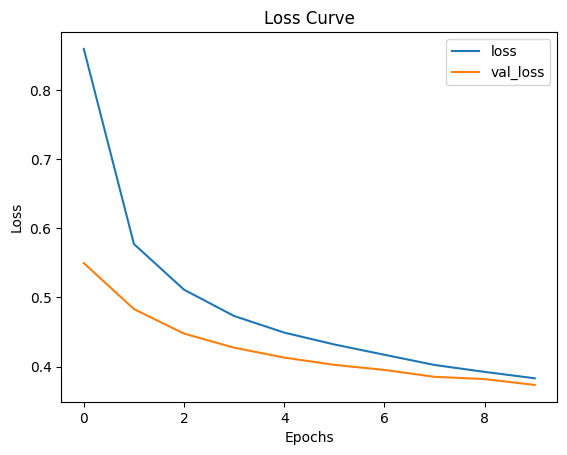

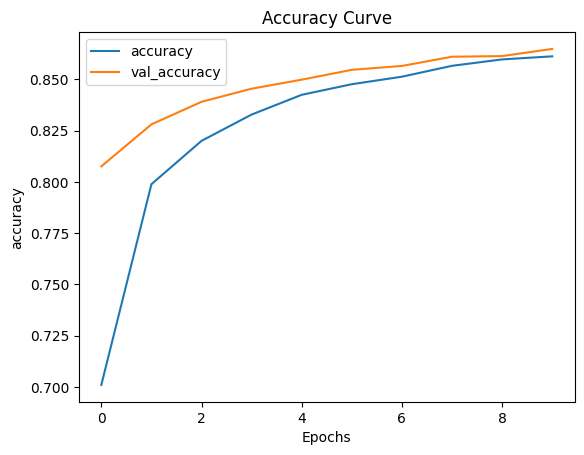

In [485]:
plot_loss_curve(h.history)
plot_accuracy_curve(h.history)

# Adam optimiser (Momentum)

In [486]:
adam = tf.keras.optimizers.Adam(
    learning_rate=0.01,
    beta_1=0.9,
    beta_2=0.999)

In [487]:
model = Sequential([
    Dense(units=784, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    Dense(units=128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    Dense(units=10, activation="softmax"),
])
model.compile(loss="categorical_crossentropy", optimizer=adam, metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.6021 - loss: 1.1789 - val_accuracy: 0.7692 - val_loss: 0.6470
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.6734 - loss: 0.9025 - val_accuracy: 0.7795 - val_loss: 0.6315
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.6777 - loss: 0.8882 - val_accuracy: 0.7691 - val_loss: 0.6615
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.6769 - loss: 0.8958 - val_accuracy: 0.7506 - val_loss: 0.6559
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.6861 - loss: 0.9001 - val_accuracy: 0.7918 - val_loss: 0.6311
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.6947 - loss: 0.8656 - val_accuracy: 0.7772 - val_loss: 0.6270
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - accuracy: 0.6851 - loss: 0.8742 - val_accuracy: 0.7874 - val_loss: 0.6347
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.6923 -

In [488]:
histos['Adam'] = h

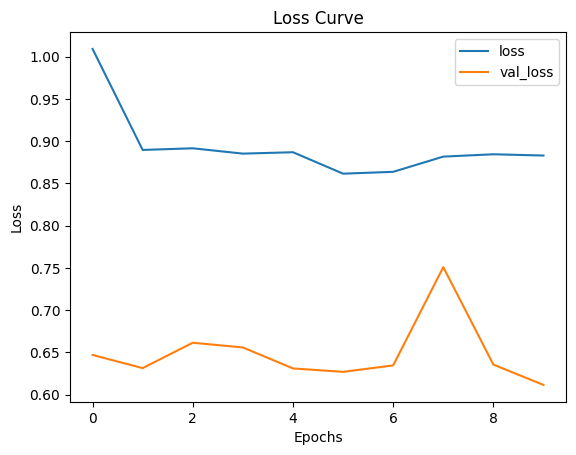

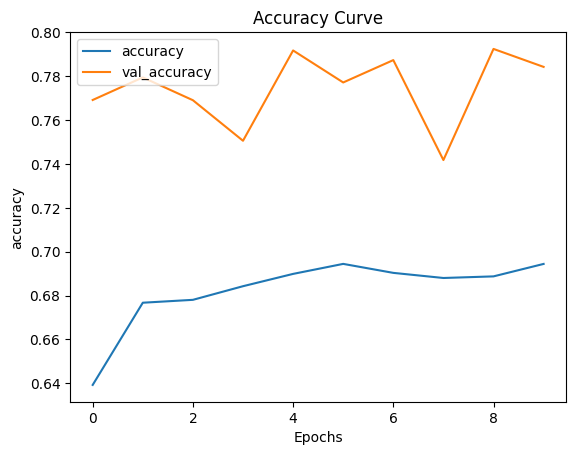

In [489]:
plot_loss_curve(h.history)
plot_accuracy_curve(h.history)

In [490]:
model.summary()

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_87 (Dense)                │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (32, 784)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (32, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,151,632 (8.21 MB)

 Trainable params: 717,210 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,434,422 (5.47 MB)

# Model Checkpoint

In [491]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [492]:
best_model = "best_model.h5"

model_ckp = ModelCheckpoint(
    filepath=best_model,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True
)

In [493]:
model = Sequential([
    Dense(units=784, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    Dense(units=128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    Dense(units=10, activation="softmax"),
])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels,
              epochs=nb_epochs,
              validation_data=(a_test_images, test_labels),
              callbacks =[model_ckp])
# default: epochs=50

Epoch 1/10
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5995 - loss: 1.1413

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.5996 - loss: 1.1409 - val_accuracy: 0.8024 - val_loss: 0.5562
Epoch 2/10
1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7935 - loss: 0.5951

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7935 - loss: 0.5950 - val_accuracy: 0.8255 - val_loss: 0.4855
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8159 - loss: 0.5237

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8159 - loss: 0.5237 - val_accuracy: 0.8412 - val_loss: 0.4489
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8304 - loss: 0.4773 - val_accuracy: 0.8392 - val_loss: 0.4418
Epoch 5/10
1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8415 - loss: 0.4516

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8415 - loss: 0.4516 - val_accuracy: 0.8492 - val_loss: 0.4167
Epoch 6/10
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8442 - loss: 0.4345

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8442 - loss: 0.4345 - val_accuracy: 0.8565 - val_loss: 0.3997
Epoch 7/10
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8526 - loss: 0.4204

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8526 - loss: 0.4204 - val_accuracy: 0.8587 - val_loss: 0.3908
Epoch 8/10
1870/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8548 - loss: 0.4083

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8549 - loss: 0.4083 - val_accuracy: 0.8599 - val_loss: 0.3873
Epoch 9/10
1868/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8612 - loss: 0.3929

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8612 - loss: 0.3929 - val_accuracy: 0.8651 - val_loss: 0.3753
Epoch 10/10
1869/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8646 - loss: 0.3812

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8646 - loss: 0.3812 - val_accuracy: 0.8672 - val_loss: 0.3690


In [494]:
model_save = tf.keras.models.load_model('best_model.h5')

In [495]:
model_save.evaluate(a_test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8721 - loss: 0.3630


[0.3690266013145447, 0.8672000169754028]

# Early Stopping

In [496]:
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5)

In [497]:
model_ckp

In [498]:
model = Sequential([ Dense(units=784, activation="relu"),
                    tf.keras.layers.Dropout(0.5),
                    Dense(units=128, activation="relu"),
                     tf.keras.layers.Dropout(0.3),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels,
              epochs=1000,
              validation_data=(a_test_images, test_labels),
              callbacks =[model_ckp, stop])
# default: epochs=1000

Epoch 1/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.5967 - loss: 1.1591 - val_accuracy: 0.7939 - val_loss: 0.5687
Epoch 2/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.7894 - loss: 0.6038 - val_accuracy: 0.8303 - val_loss: 0.4833
Epoch 3/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8174 - loss: 0.5246 - val_accuracy: 0.8358 - val_loss: 0.4553
Epoch 4/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8267 - loss: 0.4776 - val_accuracy: 0.8452 - val_loss: 0.4298
Epoch 5/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8393 - loss: 0.4519 - val_accuracy: 0.8494 - val_loss: 0.4171
Epoch 6/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8467 - loss: 0.4320 - val_accuracy: 0.8533 - val_loss: 0.4034
Epoch 7/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8503 - loss: 0.4154 - val_accuracy: 0.8552 - val_loss: 0.3937
Epoch 8/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy:

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8646 - loss: 0.3753 - val_accuracy: 0.8674 - val_loss: 0.3673
Epoch 12/1000
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8688 - loss: 0.3661

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8688 - loss: 0.3661 - val_accuracy: 0.8687 - val_loss: 0.3623
Epoch 13/1000
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8714 - loss: 0.3665

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8714 - loss: 0.3665 - val_accuracy: 0.8706 - val_loss: 0.3596
Epoch 14/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8709 - loss: 0.3592 - val_accuracy: 0.8688 - val_loss: 0.3591
Epoch 15/1000
1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8760 - loss: 0.3474

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8760 - loss: 0.3474 - val_accuracy: 0.8716 - val_loss: 0.3548
Epoch 16/1000
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8740 - loss: 0.3512

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.8740 - loss: 0.3512 - val_accuracy: 0.8731 - val_loss: 0.3505
Epoch 17/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8786 - loss: 0.3379 - val_accuracy: 0.8693 - val_loss: 0.3559
Epoch 18/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8807 - loss: 0.3294 - val_accuracy: 0.8702 - val_loss: 0.3554
Epoch 19/1000
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8799 - loss: 0.3318

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8799 - loss: 0.3318 - val_accuracy: 0.8757 - val_loss: 0.3425
Epoch 20/1000
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8821 - loss: 0.3271

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8821 - loss: 0.3271 - val_accuracy: 0.8763 - val_loss: 0.3395
Epoch 21/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8842 - loss: 0.3200

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8842 - loss: 0.3200 - val_accuracy: 0.8789 - val_loss: 0.3377
Epoch 22/1000
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8866 - loss: 0.3151

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8866 - loss: 0.3151 - val_accuracy: 0.8795 - val_loss: 0.3358
Epoch 23/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8906 - loss: 0.3107 - val_accuracy: 0.8780 - val_loss: 0.3321
Epoch 24/1000
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8861 - loss: 0.3145

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8861 - loss: 0.3145 - val_accuracy: 0.8801 - val_loss: 0.3320
Epoch 25/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8871 - loss: 0.3131

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8872 - loss: 0.3131 - val_accuracy: 0.8810 - val_loss: 0.3283
Epoch 26/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8882 - loss: 0.3056 - val_accuracy: 0.8799 - val_loss: 0.3307
Epoch 27/1000
1868/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8921 - loss: 0.2980

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.8921 - loss: 0.2980 - val_accuracy: 0.8823 - val_loss: 0.3269
Epoch 28/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8903 - loss: 0.3001 - val_accuracy: 0.8810 - val_loss: 0.3230
Epoch 29/1000
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8932 - loss: 0.2950

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8932 - loss: 0.2950 - val_accuracy: 0.8829 - val_loss: 0.3230
Epoch 30/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8914 - loss: 0.2956 - val_accuracy: 0.8823 - val_loss: 0.3241
Epoch 31/1000
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8938 - loss: 0.2912

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8938 - loss: 0.2912 - val_accuracy: 0.8836 - val_loss: 0.3221
Epoch 32/1000
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8959 - loss: 0.2856

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8959 - loss: 0.2856 - val_accuracy: 0.8859 - val_loss: 0.3199
Epoch 33/1000
1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8963 - loss: 0.2835

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8963 - loss: 0.2835 - val_accuracy: 0.8864 - val_loss: 0.3219
Epoch 34/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8977 - loss: 0.2829 - val_accuracy: 0.8831 - val_loss: 0.3240
Epoch 35/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9005 - loss: 0.2720 - val_accuracy: 0.8862 - val_loss: 0.3123
Epoch 36/1000
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8984 - loss: 0.2778

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8984 - loss: 0.2778 - val_accuracy: 0.8874 - val_loss: 0.3164
Epoch 37/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8983 - loss: 0.2774 - val_accuracy: 0.8863 - val_loss: 0.3173
Epoch 38/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8987 - loss: 0.2739 - val_accuracy: 0.8874 - val_loss: 0.3134
Epoch 39/1000
1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9029 - loss: 0.2715

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9029 - loss: 0.2715 - val_accuracy: 0.8886 - val_loss: 0.3128
Epoch 40/1000
1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9011 - loss: 0.2697

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9011 - loss: 0.2697 - val_accuracy: 0.8902 - val_loss: 0.3110
Epoch 41/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9037 - loss: 0.2642 - val_accuracy: 0.8878 - val_loss: 0.3116
Epoch 42/1000
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9016 - loss: 0.2641

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9016 - loss: 0.2641 - val_accuracy: 0.8927 - val_loss: 0.3059
Epoch 43/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9043 - loss: 0.2615 - val_accuracy: 0.8914 - val_loss: 0.3069
Epoch 44/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9059 - loss: 0.2581 - val_accuracy: 0.8895 - val_loss: 0.3094
Epoch 45/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9089 - loss: 0.2557 - val_accuracy: 0.8913 - val_loss: 0.3074
Epoch 46/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9078 - loss: 0.2505 - val_accuracy: 0.8898 - val_loss: 0.3120
Epoch 47/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9053 - loss: 0.2529 - val_accuracy: 0.8892 - val_loss: 0.3129


In [499]:
model_save = tf.keras.models.load_model('best_model.h5')
model_save.evaluate(a_test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8927 - loss: 0.3062


[0.3058920204639435, 0.8927000164985657]

In [500]:
arr=np.array([
      [1,2,3],
      [4,5,6]
    ])
print(arr)
arr.ndim

# type(h)
h.history['accuracy'][-1], h.history['loss'][-1]
histos['callbacks'] = h

[[1 2 3]
 [4 5 6]]


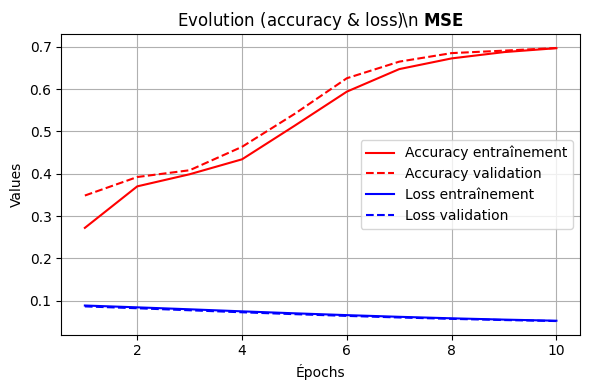

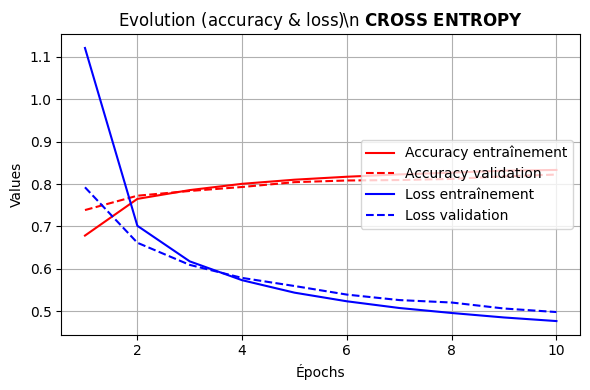

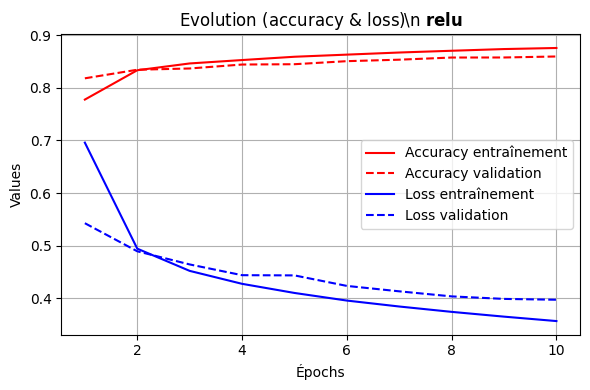

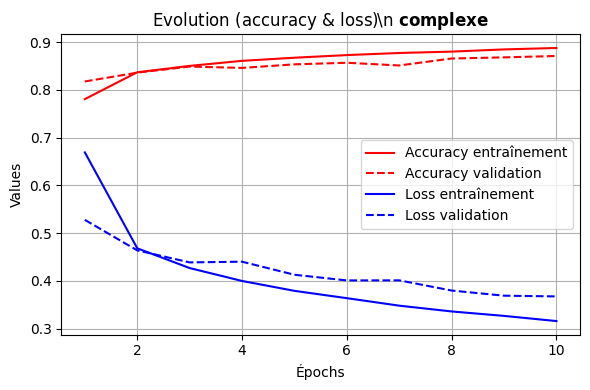

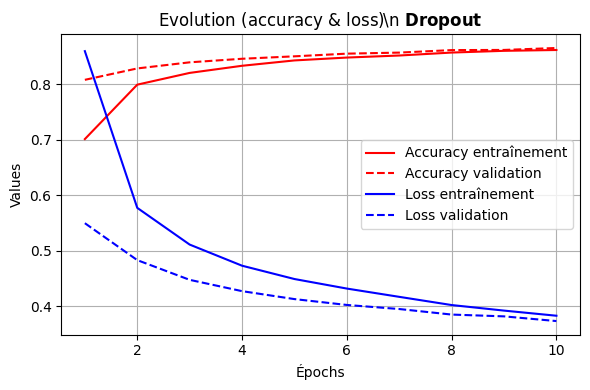

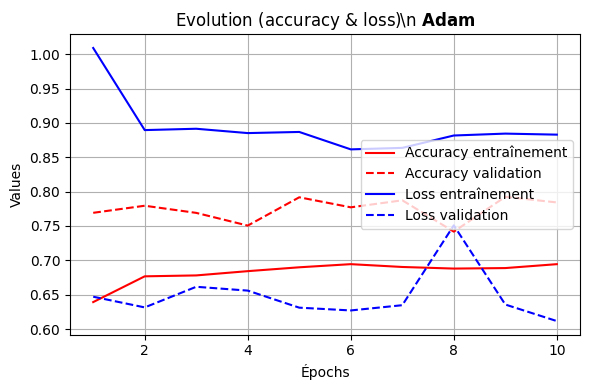

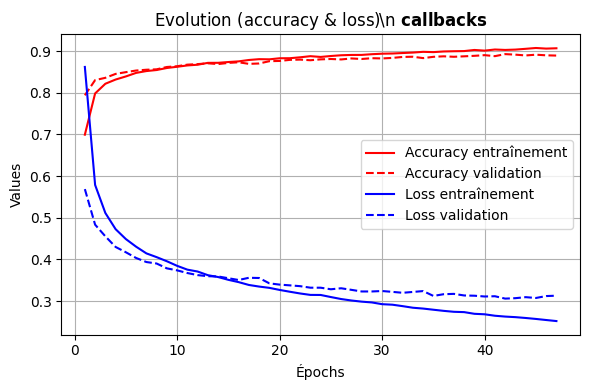

In [501]:
import matplotlib.pyplot as plt

def graph4val(history, name='ok'):

    # Récupération des métriques
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Création de la figure
    plt.figure(figsize=(6, 4))

    # Accuracy
    plt.plot(epochs, acc, 'r-', label='Accuracy entraînement')
    plt.plot(epochs, val_acc, 'r--', label='Accuracy validation')

    # Loss
    plt.plot(epochs, loss, 'b-', label='Loss entraînement')
    plt.plot(epochs, val_loss, 'b--', label='Loss validation')

    # Mise en forme
    name = name.replace(" ", r"\ ")
    plt.title(rf"Evolution (accuracy & loss)\n $\mathbf{{{name}}}$")
    plt.xlabel("Epochs")
    plt.ylabel("Values")
    plt.legend(loc="center right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()



modes = ['MSE', 'CROSS ENTROPY', 'relu', 'complexe', 'Dropout', 'Adam','callbacks']
for mode in modes:
  graph4val(histos[mode], mode)

## Voici les 4 courbes clés pour suivre l’apprentissage du modèle : accuracy et loss sur entraînement et validation.

Visualisons clairement :

* Si le modèle progresse (accuracy monte, loss descendent),

* S’il généralise bien (val_accuracy proche de accuracy),

* Ou s’il sur-apprend (val_loss qui remonte alors que loss descend).

## 📊 Lecture des courbes

* Courbes rouges : accuracy (entraînement et validation)

* Courbes bleues : loss (entraînement et validation)

* Si les courbes de validation divergent de celles d’entraînement, c’est un signal d’overfitting.

* Si les 4 courbes convergent bien, le model est stable et performant.

In [502]:
import pandas as pd

# Initialiser une liste pour stocker les résultats
results = []

for mode in modes:
    h = histos[mode].history
    results.append({
        'Méthode': mode,
        'Accuracy': h['accuracy'][-1],
        'Val Accuracy': h['val_accuracy'][-1],
        'Loss': h['loss'][-1],
        'Val Loss': h['val_loss'][-1]
    })

# Créer le DataFrame
df = pd.DataFrame(results)
df

,Méthode,Accuracy,Val Accuracy,Loss,Val Loss
0,MSE,0.696733,0.6972,0.052498,0.051673
1,CROSS ENTROPY,0.833267,0.8224,0.476973,0.498230
2,relu,0.875633,0.8595,0.356807,0.397314
3,complexe,0.887750,0.8710,0.315603,0.367238
4,Dropout,0.861283,0.8649,0.383123,0.373521
5,Adam,0.694417,0.7843,0.883028,0.611565
6,callbacks,0.906717,0.8892,0.251982,0.312896


In [503]:
# Pour accuracy et val_accuracy → max
best_acc_idx = df['Accuracy'].idxmax()
best_val_acc_idx = df['Val Accuracy'].idxmax()

best_acc = df.loc[best_acc_idx, 'Méthode']
best_val_acc = df.loc[best_val_acc_idx, 'Méthode']

score_acc = df.loc[best_acc_idx, 'Accuracy']
score_val_acc = df.loc[best_val_acc_idx, 'Val Accuracy']

# Pour loss et val_loss → min
best_loss_idx = df['Loss'].idxmin()
best_val_loss_idx = df['Val Loss'].idxmin()

best_loss = df.loc[best_loss_idx, 'Méthode']
best_val_loss = df.loc[best_val_loss_idx, 'Méthode']

score_loss = df.loc[best_loss_idx, 'Loss']
score_val_loss = df.loc[best_val_loss_idx, 'Val Loss']

# Résumé sous forme de tableau
summary = pd.DataFrame({
    'Métrique': ['Accuracy', 'Val Accuracy', 'Loss', 'Val Loss'],
    'Meilleure Méthode': [best_acc, best_val_acc, best_loss, best_val_loss],
    'Meilleur Score': [score_acc, score_val_acc, score_loss, score_val_loss]
})

print(summary)

       Métrique Meilleure Méthode  Meilleur Score
0      Accuracy         callbacks        0.906717
1  Val Accuracy         callbacks        0.889200
2          Loss               MSE        0.052498
3      Val Loss               MSE        0.051673


# Predictions

In [504]:
model_save = tf.keras.models.load_model('best_model.h5')

In [505]:
model_save.summary()

Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_93 (Dense)                │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (32, 784)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (32, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 717,212 (2.74 MB)

 Trainable params: 717,210 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [506]:
a_test_images[2500]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.02352941,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.18039216,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.19607843, 0.84705882, 1.        , 0.29411765, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.05490196, 0.74509804, 0.92156863, 0.79215686, 0.17254902,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.2627451 , 0.95686275, 0.92941176,
       0.91372549, 0.94901961, 0.92156863, 0.80392157, 0.71764706,
       0.57254902, 0.77254902, 0.88235294, 1.        , 0.95294

In [507]:
a_test_images[0].shape

(784,)

In [508]:
test_labels[2500]

array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])

In [509]:
np.argmax(test_labels[2500])

np.int64(6)

In [510]:
labels[6]

'shirt'

In [511]:
pred = model_save.predict(a_test_images[2500].reshape((1, 784)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


In [512]:
pred

array([[1.9487870e-03, 7.0153925e-05, 6.5285349e-01, 6.3682394e-04,
        9.3912147e-03, 2.0063319e-05, 3.3486909e-01, 6.8658466e-07,
        2.0426462e-04, 5.3870426e-06]], dtype=float32)

In [513]:
np.argmax(pred)

np.int64(2)

In [514]:
labels[2] # Bad predict

'pullover'

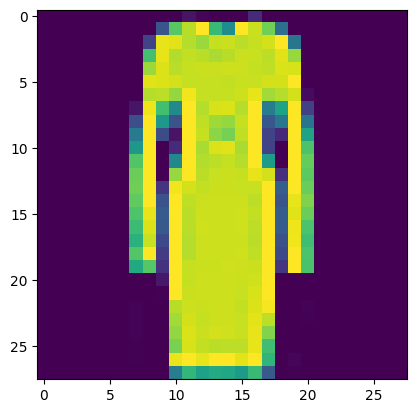

In [515]:
import matplotlib.pyplot as plt
plt.imshow(training_images[2500])
# plt.title(labels[training_labels[45]])
plt.show()

In [516]:
a_test_images[12].shape

(784,)

In [517]:
test_labels[12]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [518]:
labels[np.argmax(test_labels[12])]

'sneaker'

In [519]:
pred = model_save.predict(a_test_images[7].reshape((1, 784)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


In [520]:
pred

array([[3.7948459e-05, 1.6783947e-08, 2.5320734e-04, 5.7550333e-06,
        5.7489392e-03, 6.6607391e-09, 9.9395353e-01, 1.0977524e-10,
        5.2031351e-07, 1.5431661e-08]], dtype=float32)

In [521]:
np.argmax(pred)

np.int64(6)

In [522]:
labels[6] # Bad predict

'shirt'

In [523]:
a_test_images[0].shape

(784,)

In [524]:
test_labels[12]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [525]:
labels[np.argmax(test_labels[00])]

'ankle boot'

In [526]:
pred = model_save.predict(a_test_images[0].reshape((1, 784)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


In [527]:
labels[np.argmax(pred)]

'ankle boot'

In [528]:
# (60000, 784) (1, 784)

In [530]:
a_test_images.shape

(10000, 784)

Image Index,Original Image,Predicted Label,Correct,Image Index,Original Image,Predicted Label,Correct,Image Index,Original Image,Predicted Label,Correct
4815,,sandals,✅,441,,sneaker,❌,6376,,trouser,✅
6743,,sneaker,✅,3218,,sandals,✅,6838,,trouser,✅
916,,t-shirt/top,✅,8652,,coat,✅,9476,,ankle boot,✅
3869,,bag,✅,6128,,sandals,✅,8365,,trouser,✅

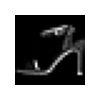
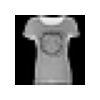
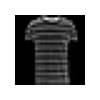
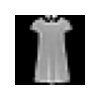
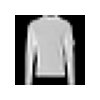
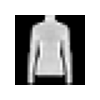
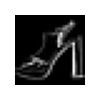
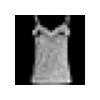
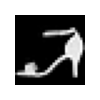
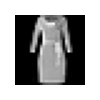
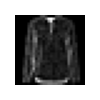
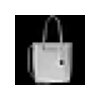

In [540]:
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import io
import base64

def display_image_table(indices, true_labels, predicted_labels, original_images):
    html = "<style> table, th, td { border: 1px solid black; text-align: center;}</style><table><tr>"
    # Add headers
    for _ in range(3):
        html += "<th>Image Index</th><th>Original Image</th><th>Predicted Label</th><th>Correct</th>"
    html += "</tr><tr>"

    for i, idx in enumerate(indices):
        correct = '✅' if true_labels[i] == predicted_labels[i] else '❌'
        # Create a plot for each image and save it as a PNG in memory
        fig, ax = plt.subplots(figsize=(1, 1))
        ax.imshow(original_images[idx], cmap='gray') # Display original image as requested
        ax.axis('off')
        plt.tight_layout()
        buf = io.BytesIO()
        plt.savefig(buf, format='png')
        plt.close(fig)
        img_base64 = base64.b64encode(buf.getvalue()).decode('utf-8')

        html += f"""
            <td>{idx}</td>
            <td><img src='data:image/png;base64,{img_base64}'/></td>
            <td>{predicted_labels[i]}</td>
            <td>{correct}</td>
        """
        # Start a new row after every 3 images
        if (i + 1) % 3 == 0:
            html += "</tr>"
            if i < len(indices) - 1:
                html += "<tr>"

    html += "</table>"
    display(HTML(html))

# Get the corresponding images and labels (using the previously generated random_indices)
sample_images_display = training_images[random_indices] # Use original images for display
sample_labels_display_text = [labels[np.argmax(label)] for label in test_labels[random_indices]]
predicted_labels_text = [labels[np.argmax(pred)] for pred in predictions]


display_image_table(random_indices, sample_labels_display_text, predicted_labels_text, training_images)

In [537]:
import random
import pandas as pd

# Select 12 random indices
random_indices = random.sample(range(a_test_images.shape[0]), 12)

# Get the corresponding images and labels
sample_images = a_test_images[random_indices]
sample_labels = test_labels[random_indices]

# Make predictions using the saved model
predictions = model_save.predict(sample_images)

# Get the predicted labels
predicted_labels = [labels[np.argmax(pred)] for pred in predictions]
true_labels = [labels[np.argmax(label)] for label in sample_labels]

# Create a DataFrame to display the results
results_df = pd.DataFrame({
    'Image Index': random_indices,
    'True Label': true_labels,
    'Predicted Label': predicted_labels
})

# Add a column for correctness
results_df['Correct'] = ['✅' if true == pred else '❌' for true, pred in zip(true_labels, predicted_labels)]

display(results_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


,Image Index,True Label,Predicted Label,Correct
0,4815,sandals,sandals,✅
1,441,ankle boot,sneaker,❌
2,6376,trouser,trouser,✅
3,6743,sneaker,sneaker,✅
4,3218,sandals,sandals,✅
5,6838,trouser,trouser,✅
6,916,t-shirt/top,t-shirt/top,✅
7,8652,coat,coat,✅
8,9476,ankle boot,ankle boot,✅
9,3869,bag,bag,✅


## Epoch 5/5

| Model         | Accuracy | Loss   | Val Accuracy | Val Loss |
|---------------|----------|--------|--------------|----------|
| MSE           | 0.5523   | 0.0708 | 0.5839       | 0.0674   |
| CROSS ENTROPY | 0.8085   | 0.5455 | 0.8037       | 0.5520   |
| relu          | 0.8570   | 0.4169 | 0.8406       | 0.4453   |
| model complexe| 0.8676   | 0.3768 | 0.8541       | 0.4082   |
| Dropout       | 0.8405   | 0.4501 | 0.8492       | 0.4157   |
| Adam          | 0.6805   | 0.8744 | 0.7445       | 0.6483   |
| Callbacks     | 0.8400   | 0.4521 | 0.8515       | 0.4164   |

## Epoch 50/50

| Model         | Accuracy | Loss   | Val Accuracy | Val Loss |
|---------------|----------|--------|--------------|----------|
| MSE           | 0.7930   | 0.0310 | 0.7834       | 0.0319   |
| CROSS ENTROPY | 0.8674   | 0.3769 | 0.8482       | 0.4202   |
| relu          | 0.9247   | 0.2136 | 0.8892       | 0.3137   |
| model complexe| 0.9536   | 0.1322 | 0.8966       | 0.3154   |
| Dropout       | 0.9107   | 0.2454 | 0.8954       | 0.3021   |
| Adam          | 0.6543   | 0.9675 | 0.7221       | 0.7787   |
| Callbacks     | 0.8815   | 0.3273 | 0.8764       | 0.3416   |

(Callbacks s'est arrêté à 20/50)